# Percobaan Pengaruh Banyak Cell LSTM per Layer

#### Import Dataset

In [8]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization, Embedding, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras import Sequential, Input
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Seeding

In [9]:
import random
import os

# Atur seed
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
tf.keras.utils.set_random_seed(seed_value)
tf.config.experimental.enable_op_determinism()
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '42'

#### Load Dataset

In [10]:
# Pemetaan label ke angka
label_mapping = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

# Load Dataset NusaX-Sentiment
# Train dataset
df_train = pd.read_csv("../../datasets/indonesian/train.csv")
train_texts = df_train['text'].astype(str).tolist()
df_train['label'] = df_train['label'].map(label_mapping) # Pemetaan label ke angka
train_labels = df_train['label'].astype(int).tolist()

# Validation dataset
df_val = pd.read_csv("../../datasets/indonesian/valid.csv")
val_texts = df_val['text'].astype(str).tolist()
df_val['label'] = df_val['label'].map(label_mapping) # Pemetaan label ke angka
val_labels = df_val['label'].astype(int).tolist()

# Test dataset
df_test = pd.read_csv("../../datasets/indonesian/test.csv")
test_texts = df_test['text'].astype(str).tolist()
df_test['label'] = df_test['label'].map(label_mapping) # Pemetaan label ke angka
test_labels = df_test['label'].astype(int).tolist()

#### Preprocessing - Tokenization & Vectorization

In [11]:
# Split data
X_train, X_val, X_test, y_train, y_val, y_test = train_texts, val_texts, test_texts, train_labels, val_labels, test_labels

# TextVectorization (Tokenization)
MAX_TOKENS = 10000      # Jumlah maksimum kata unik
MAX_LEN = 100           # Panjang maksimum sequence

vectorizer = TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode='int',
    output_sequence_length=MAX_LEN,
    standardize='lower_and_strip_punctuation',
    split='whitespace',
    pad_to_max_tokens=True,
    ngrams=None,
)
vectorizer.adapt(X_train)

In [12]:
# 4. Dataset pipeline
def prepare_dataset(X, y):
    X_vec = vectorizer(tf.constant(X))
    return tf.data.Dataset.from_tensor_slices((X_vec, y)).batch(32).prefetch(tf.data.AUTOTUNE)

train_ds = prepare_dataset(X_train, y_train)
val_ds = prepare_dataset(X_val, y_val)
test_ds = prepare_dataset(X_test, y_test)

In [13]:
EMBED_DIM = 128

## Model 1: 32 Cell per Layer LSTM

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.4349 - loss: 1.0780 - val_accuracy: 0.5000 - val_loss: 1.0219
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5324 - loss: 0.9576 - val_accuracy: 0.5500 - val_loss: 0.9468
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.6123 - loss: 0.7915 - val_accuracy: 0.6100 - val_loss: 0.8515
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.7924 - loss: 0.6216 - val_accuracy: 0.7400 - val_loss: 0.6992
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9267 - loss: 0.3431 - val_accuracy: 0.7600 - val_loss: 0.7200
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9688 - loss: 0.1573 - val_accuracy: 0.7600 - val_loss: 0.7781
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9827 - loss: 0.1027 - val_accuracy: 0.7500 - val_loss: 0.8058
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9871 - loss: 0.0664 - val_accuracy: 0.7200 - v

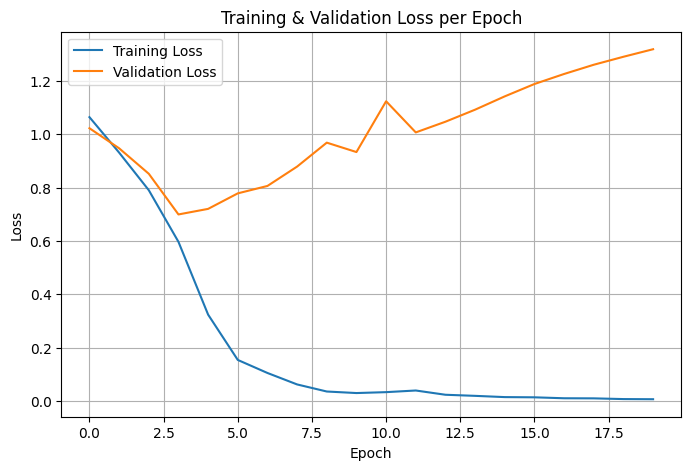

In [14]:
model1 = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=MAX_TOKENS, output_dim=EMBED_DIM),
    Bidirectional(LSTM(32, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dropout(0.5),
    Dense(3, activation='softmax')
])


model1.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    batch_size=32
)

# Prediksi di test set
predictions = model1.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)

# Hitung macro F1-Score
from sklearn.metrics import f1_score
macro_f1 = f1_score(test_labels, predicted_labels, average='macro')
print(f"Macro F1-Score: {macro_f1:.4f}")

# Plot training & validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Model 2: 64 Cell per Layer LSTM

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.4105 - loss: 1.0762 - val_accuracy: 0.5000 - val_loss: 1.0001
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.5550 - loss: 0.9282 - val_accuracy: 0.5700 - val_loss: 0.9006
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.7070 - loss: 0.7074 - val_accuracy: 0.6800 - val_loss: 0.7359
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.8775 - loss: 0.3670 - val_accuracy: 0.7200 - val_loss: 0.7183
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.9786 - loss: 0.1143 - val_accuracy: 0.6700 - val_loss: 1.0375
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9825 - loss: 0.0999 - val_accuracy: 0.6900 - val_loss: 1.0390
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.9989 - loss: 0.0346 - val_accuracy: 0.7200 - val_loss: 1.0678
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 1.0000 - loss: 0.0152 - val_accuracy: 0.7200 - v

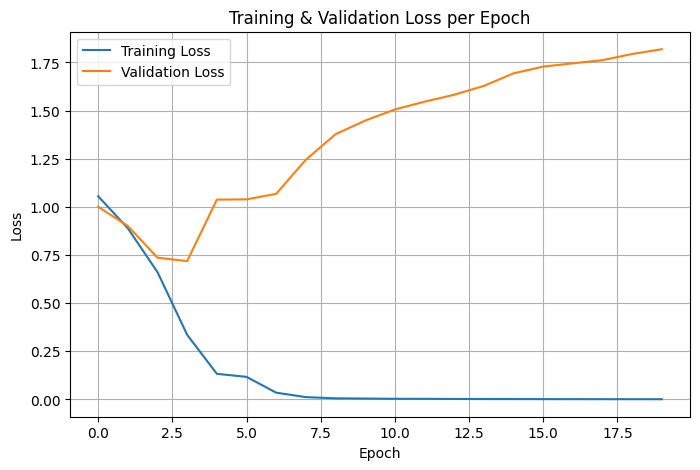

In [15]:
model2 = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=MAX_TOKENS, output_dim=EMBED_DIM),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(3, activation='softmax')
])


model2.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    batch_size=32
)

# Prediksi di test set
predictions = model2.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)

# Hitung macro F1-Score
from sklearn.metrics import f1_score
macro_f1 = f1_score(test_labels, predicted_labels, average='macro')
print(f"Macro F1-Score: {macro_f1:.4f}")

# Plot training & validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Model 3: 128 Cell per Layer LSTM

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 154ms/step - accuracy: 0.4879 - loss: 1.0594 - val_accuracy: 0.5100 - val_loss: 0.9535
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.5707 - loss: 0.8543 - val_accuracy: 0.6300 - val_loss: 0.8516
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.7027 - loss: 0.6021 - val_accuracy: 0.6400 - val_loss: 0.7892
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.8573 - loss: 0.3400 - val_accuracy: 0.7000 - val_loss: 0.9157
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.9504 - loss: 0.1560 - val_accuracy: 0.7200 - val_loss: 0.9701
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.9974 - loss: 0.0341 - val_accuracy: 0.6700 - val_loss: 1.6963
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.9667 - loss: 0.1201 - val_accuracy: 0.7300 - val_loss: 1.0794
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - accuracy: 0.9945 - loss: 0.0369 - val_accuracy: 0.

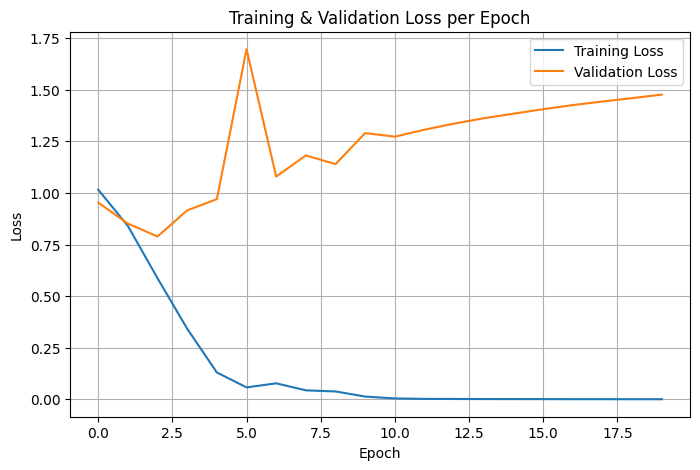

In [16]:
model3 = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=MAX_TOKENS, output_dim=EMBED_DIM),
    Bidirectional(LSTM(128, return_sequences=True)),
    Bidirectional(LSTM(128)),
    Dropout(0.5),
    Dense(3, activation='softmax')
])


model3.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    batch_size=32
)

# Prediksi di test set
predictions = model3.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)

# Hitung macro F1-Score
from sklearn.metrics import f1_score
macro_f1 = f1_score(test_labels, predicted_labels, average='macro')
print(f"Macro F1-Score: {macro_f1:.4f}")

# Plot training & validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()